In [1]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

Torch version: 2.10.0+cu128
CUDA available: True
GPU name: Tesla T4


Total dataset size: 28531
Torch version: 2.10.0+cu128
CUDA available: True
Using GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/870M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/970 [00:00<?, ?B/s]

100%|██████████| 28531/28531 [1:08:15<00:00,  6.97it/s]



Pure motivation comments kept: 2792

Overall Summary:
                                    Type  Count  Percentage_of_full_dataset
0                           Not Relevant  19940                       69.89
1  General Admiration / Positive Comment   5799                       20.33
2   Active Motivation / Ownership Desire   2792                        9.79

Pure Motivation Summary:
                                   Type  Count  \
0  Active Motivation / Ownership Desire   2792   

   Percentage_within_pure_motivation  
0                              100.0  


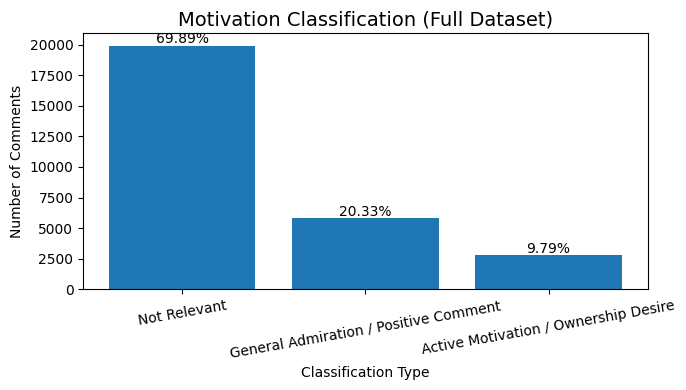


Saved files:
wwf_motivation_full_classified_strict.csv
wwf_motivation_pure_comments.csv
wwf_motivation_overall_summary.csv
wwf_motivation_pure_summary.csv
Q_motivation_overall_chart.png


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import torch
from transformers import pipeline
from tqdm import tqdm

# =========================
# 1. LOAD DATA
# =========================
file_path = r"/content/wwf_final_youtube_clean_only_english.csv"   # change if needed
df = pd.read_csv(file_path)

df = df.dropna(subset=["text_content"]).copy()
df["text_content"] = df["text_content"].astype(str).str.strip()
df = df[df["text_content"] != ""]

TOTAL_COMMENTS = len(df)
print("Total dataset size:", TOTAL_COMMENTS)

# =========================
# 2. CLEAN TEXT
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text_content"].apply(clean_text)

# =========================
# 3. GPU CHECK
# =========================
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device_id = 0 if torch.cuda.is_available() else -1
if device_id == 0:
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Using CPU.")

# =========================
# 4. LOAD MODEL
# =========================
MODEL_NAME = "MoritzLaurer/deberta-v3-large-zeroshot-v2.0"

classifier = pipeline(
    "zero-shot-classification",
    model=MODEL_NAME,
    device=device_id
)

# =========================
# 5. STRICT MOTIVATION KEYWORDS
# =========================
MOTIVATION_KEYWORDS_STRICT = [
    "i want one",
    "i want this pet",
    "i want to own",
    "i want to keep",
    "i want to have one",
    "i'm getting one",
    "im getting one",
    "i will get one",
    "i will buy one",
    "i'm buying one",
    "im buying one",
    "i need one",
    "my dream pet",
    "wish i had one",
    "i wish i had one"
]

ADMIRATION_KEYWORDS = [
    "so cute", "cute", "adorable", "beautiful", "amazing",
    "awesome", "love this", "i love this", "my favorite animal",
    "i like this animal", "pretty", "cool animal"
]

def keyword_hint(text):
    t = text.lower()

    if any(k in t for k in MOTIVATION_KEYWORDS_STRICT):
        return "Active Motivation / Ownership Desire"

    if any(k in t for k in ADMIRATION_KEYWORDS):
        return "General Admiration / Positive Comment"

    return None

# =========================
# 6. LABELS
# =========================
candidate_labels = [
    "comment expresses strong motivation or ownership desire for the exotic pet",
    "comment expresses general admiration or positive feeling but not ownership desire",
    "comment is not relevant to motivation for owning the exotic pet"
]

label_map = {
    candidate_labels[0]: "Active Motivation / Ownership Desire",
    candidate_labels[1]: "General Admiration / Positive Comment",
    candidate_labels[2]: "Not Relevant"
}

# =========================
# 7. STRICT CLASSIFICATION
# =========================
MIN_SCORE = 0.60

def classify_motivation(text):
    try:
        hint = keyword_hint(text)

        result = classifier(
            text[:512],
            candidate_labels=candidate_labels,
            multi_label=False
        )

        top_label = result["labels"][0]
        top_score = result["scores"][0]
        mapped_label = label_map[top_label]

        # Low-confidence model output: trust strong keyword hint if available
        if top_score < MIN_SCORE:
            if hint is not None:
                return hint, top_score
            else:
                return "Not Relevant", top_score

        # If model says Not Relevant but strong keyword hint exists, recover it
        if hint is not None and mapped_label == "Not Relevant" and top_score < 0.75:
            return hint, top_score

        return mapped_label, top_score

    except Exception:
        hint = keyword_hint(text)
        if hint is not None:
            return hint, 0.0
        return "Not Relevant", 0.0

tqdm.pandas()
results = df["clean_text"].progress_apply(classify_motivation)

df["motivation_type"] = results.apply(lambda x: x[0])
df["motivation_score"] = results.apply(lambda x: x[1])

# =========================
# 8. KEEP ONLY PURE MOTIVATION COMMENTS
# =========================
motivation_df = df[df["motivation_type"] == "Active Motivation / Ownership Desire"].copy()

print("\nPure motivation comments kept:", len(motivation_df))

# =========================
# 9. SUMMARIES
# =========================
overall_summary = df["motivation_type"].value_counts().reset_index()
overall_summary.columns = ["Type", "Count"]
overall_summary["Percentage_of_full_dataset"] = (overall_summary["Count"] / TOTAL_COMMENTS * 100).round(2)

pure_summary = motivation_df["motivation_type"].value_counts().reset_index()
pure_summary.columns = ["Type", "Count"]
pure_summary["Percentage_within_pure_motivation"] = (pure_summary["Count"] / len(motivation_df) * 100).round(2)

print("\nOverall Summary:")
print(overall_summary)

print("\nPure Motivation Summary:")
print(pure_summary)

# =========================
# 10. SAVE FILES
# =========================
df.to_csv("wwf_motivation_full_classified_strict.csv", index=False)
motivation_df.to_csv("wwf_motivation_pure_comments.csv", index=False)
overall_summary.to_csv("wwf_motivation_overall_summary.csv", index=False)
pure_summary.to_csv("wwf_motivation_pure_summary.csv", index=False)

# =========================
# 11. CHART 1 - OVERALL
# =========================
plt.figure(figsize=(7, 4))
bars = plt.bar(overall_summary["Type"], overall_summary["Count"])

for i, row in overall_summary.iterrows():
    plt.text(
        i,
        row["Count"] + max(overall_summary["Count"]) * 0.01,
        f"{row['Percentage_of_full_dataset']}%",
        ha="center",
        fontsize=10
    )

plt.title("Motivation Classification (Full Dataset)", fontsize=14)
plt.xlabel("Classification Type")
plt.ylabel("Number of Comments")
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("Q_motivation_overall_chart.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 12. DONE
# =========================
print("\nSaved files:")
print("wwf_motivation_full_classified_strict.csv")
print("wwf_motivation_pure_comments.csv")
print("wwf_motivation_overall_summary.csv")
print("wwf_motivation_pure_summary.csv")
print("Q_motivation_overall_chart.png")